# BloodPressure.

## Exploratory data analysis Section:
    1. Univariate Analysis
    2. Bivariate Analysis
    3. Multi-variate Analysis

### Import the libraries

In [38]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import the RTL module

from Melted import df_melt
from visualization import Plot
from StatMelt import average_melt

ImportError: cannot import name 'average_melt' from 'StatMelt' (/Users/pouniq/BloodPressure/utils/StatMelt.py)

### Read the dataset

In [17]:
# !*pip install openpyxl
df = pd.read_csv('../Data/BP.csv')
# df = pd.read_excel('BP.xlsx')

### Decompose the dataset into Left and Right Arm

In [19]:
df_half = df.loc[0:29].copy()
df_half['day'] = df_half['day'].ffill()
df_half['hand'] = df_half['hand'].ffill()
df_half['date'] = df_half['date'].ffill()

df_half = df_half.dropna()
col_num = ['morning', 'noon', 'night']
col_cat = ['hand', 'type']

# filtering the right hand
df_half_R = df_half[df_half['hand'] == 'R']
df_half_R = df_half_R.drop('hand' , axis=1)
df_half_R_s = df_half_R[df_half_R['type'] == 'Systolic'] 
df_half_R_d =  df_half_R[df_half_R['type'] == 'Diastolic'] 
df_half_R_p =  df_half_R[df_half_R['type'] == 'Pulse']

# filtering the left hand
df_half_L = df_half[df_half['hand'] == 'L']
df_half_L = df_half_L.drop('hand' , axis=1)
df_half_L_s = df_half_L[df_half_L['type'] == 'Systolic'] 
df_half_L_d =  df_half_L[df_half_L['type'] == 'Diastolic'] 
df_half_L_p =  df_half_L[df_half_L['type'] == 'Pulse']

### Making Dataframe usable.

In [27]:
# melt the dataset.
df_p = df_melt(df_half_L_p)
df_s = df_melt(df_half_L_s)
df_d = df_melt(df_half_L_d)

    day       date   type time_of_day  measurement
0   3.0  1405/2/10  Pulse     morning         64.0
1   3.0  1405/2/10  Pulse        noon         67.0
2   3.0  1405/2/10  Pulse       night         69.0
3   4.0  1405/2/11  Pulse     morning         54.0
4   4.0  1405/2/11  Pulse        noon         72.0
5   4.0  1405/2/11  Pulse       night         74.0
6   1.0   1405/2/8  Pulse     morning         65.0
7   1.0   1405/2/8  Pulse        noon         83.0
8   1.0   1405/2/8  Pulse       night         62.0
9   2.0   1405/2/9  Pulse     morning         60.0
10  2.0   1405/2/9  Pulse        noon         64.0
11  2.0   1405/2/9  Pulse       night         69.0
    day       date      type time_of_day  measurement
0   3.0  1405/2/10  Systolic     morning        127.0
1   3.0  1405/2/10  Systolic        noon        113.0
2   3.0  1405/2/10  Systolic       night        138.0
3   4.0  1405/2/11  Systolic     morning        128.0
4   4.0  1405/2/11  Systolic        noon        141.0
5   4.0  1405

In [41]:
melted_list = [df_p , df_s , df_d]
name = ['pulse', 'Systolic', 'Diastolic']

for d, n in zip(melted_list,name):
    print('-'*24 , f'Average value for {n}', ''*25)
    print(d.groupby('time_of_day', observed=False )['measurement'].mean())
    print('-'*50)


------------------------ Average value for pulse 
time_of_day
morning    60.75
noon       71.50
night      68.50
Name: measurement, dtype: float64
--------------------------------------------------
------------------------ Average value for Systolic 
time_of_day
morning    138.75
noon       133.75
night      138.00
Name: measurement, dtype: float64
--------------------------------------------------
------------------------ Average value for Diastolic 
time_of_day
morning    81.25
noon       72.25
night      76.50
Name: measurement, dtype: float64
--------------------------------------------------


# this is were you develope T-Test to comapare if 
# getting BP with Right or Left hand would differ 
# in any case.


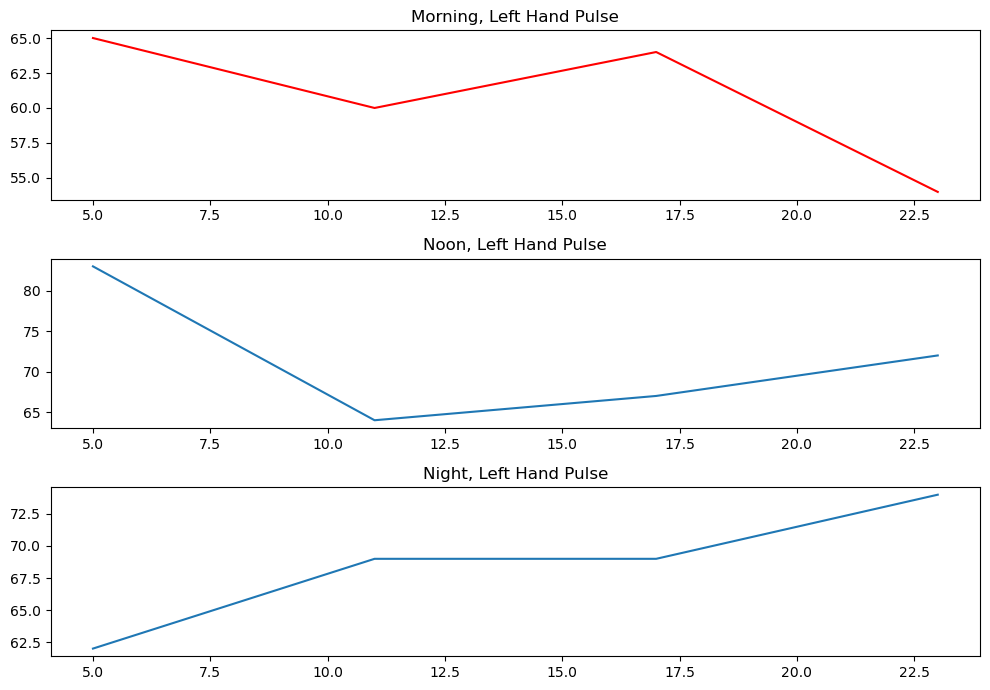

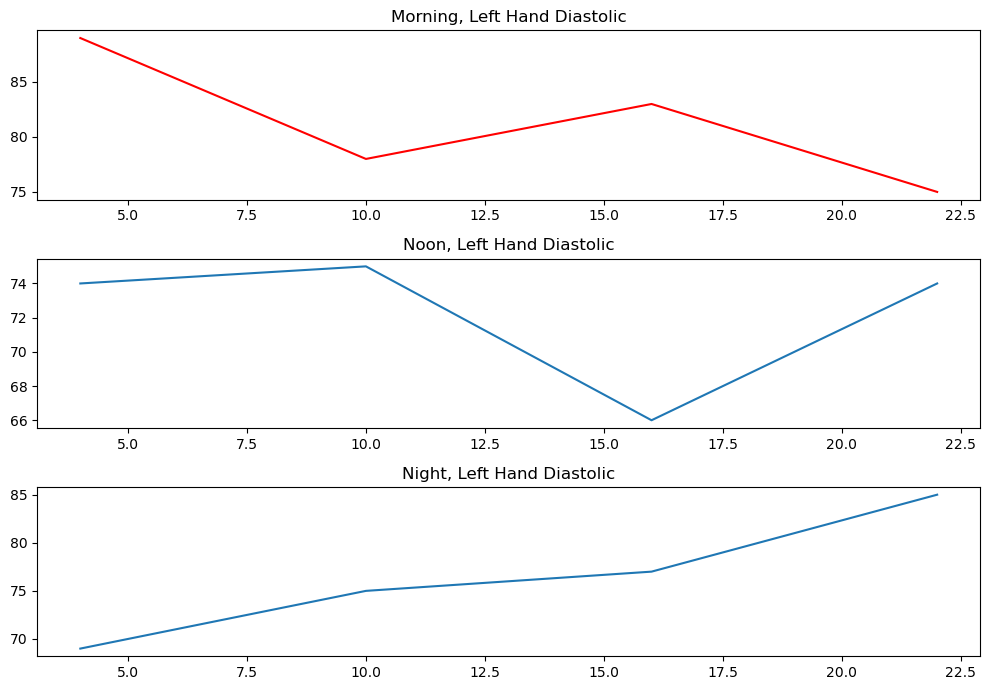

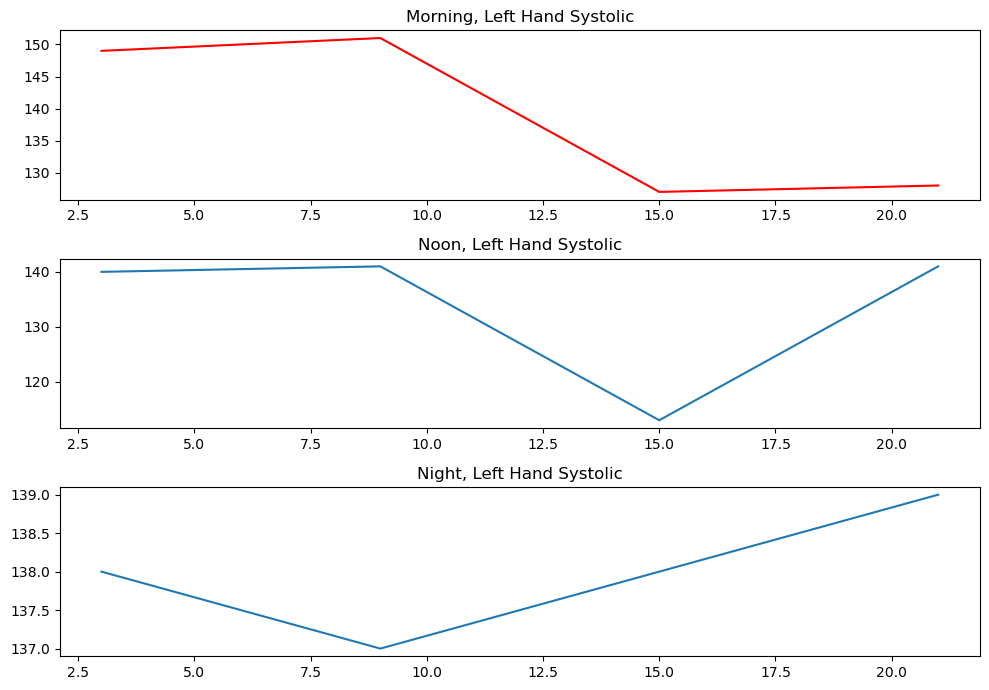

In [31]:
# Analysis of Left hand

datasets = [df_half_L_p , df_half_L_d , df_half_L_s]
names = ['Pulse' , 'Diastolic', 'Systolic']

Plot(datasets, names)

NameError: name 'meltedList' is not defined